# Проект: Анализ данных Brazilian E-Commerce (Olist)
## Цель: Предобработка данных, исследовательский анализ и проведение A/B-теста

Датасет состоит из нескольких CSV-файлов, описывающих заказы, клиентов, товары, отзывы и платежи.
Задача A/B-теста: оценить влияние новой системы рекомендаций на конверсию и средний чек.
Гипотеза: Внедрение персонализированных рекомендаций увеличит среднюю стоимость заказа (AOV) и конверсию.

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')


In [123]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline

In [124]:
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

print("Размеры датасетов:")
print(f"Orders: {orders.shape}")
print(f"Order items: {order_items.shape}")
print(f"Customers: {customers.shape}")

Размеры датасетов:
Orders: (99441, 8)
Order items: (112650, 7)
Customers: (99441, 5)


## 1. Предобработка данных
На этом этапе:
- Приведем типы данных к корректным
- Обработаем пропуски
- Объединим необходимые таблицы
- Создадим базовые признаки

In [125]:
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

for col in date_columns:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col])

In [126]:
print("Пропуски в orders:")
print(orders.isnull().sum())

Пропуски в orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [127]:
# Собираем полную информацию по каждому товару в заказе
order_details = order_items.merge(
    products[['product_id', 'product_category_name']], 
    on='product_id', 
    how='left'
)

# Агрегируем заказы
order_summary = order_details.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum',
    'order_item_id': 'count',
    'product_category_name': lambda x: x.nunique()  
}).rename(columns={
    'order_item_id': 'item_count',
    'product_category_name': 'unique_categories',
    'price': 'total_price',
    'freight_value': 'total_freight'
})

# Добавляем стоимость доставки к итоговой сумме и информацию о платежах
order_summary['order_total'] = order_summary['total_price'] + order_summary['total_freight']

payment_summary = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': lambda x: ', '.join(x.unique())
}).rename(columns={'payment_value': 'total_paid'})

# Объединяем 
merged = orders.merge(order_summary, on='order_id', how='left')
merged = merged.merge(payment_summary, on='order_id', how='left')
merged = merged.merge(customers, on='customer_id', how='left')

merged.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,item_count,unique_categories,order_total,total_paid,payment_type,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1.0,1.0,38.71,38.71,"credit_card, voucher",7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1.0,1.0,141.46,141.46,boleto,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1.0,1.0,179.12,179.12,credit_card,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [128]:
# Создаем целевые признаки для A/B-теста
merged['conversion'] = merged['order_status'].apply(
    lambda x: 1 if x in ['delivered', 'shipped'] else 0
)
merged['order_value'] = merged['order_total'].fillna(0)

# Создаем временные признаки для анализа
merged['purchase_month'] = merged['order_purchase_timestamp'].dt.to_period('M')
merged['purchase_weekday'] = merged['order_purchase_timestamp'].dt.dayofweek
merged['purchase_hour'] = merged['order_purchase_timestamp'].dt.hour

print(f"Итоговый датафрейм: {merged.shape}")

merged.head(3)

Итоговый датафрейм: (99441, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,...,payment_type,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,conversion,order_value,purchase_month,purchase_weekday,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,...,"credit_card, voucher",7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,38.71,2017-10,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,...,boleto,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,141.46,2018-07,1,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,...,credit_card,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,179.12,2018-08,2,8


In [129]:
print("Пропуски после объединения:")
print(merged.isnull().sum())

Пропуски после объединения:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
total_price                       775
total_freight                     775
item_count                        775
unique_categories                 775
order_total                       775
total_paid                          1
payment_type                        1
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
conversion                          0
order_value                         0
purchase_month                      0
purchase_weekday                    0
purchase_hour                       0
dtype: int64


## 2. Разведочный анализ данных
Исследуем распределения ключевых метрик перед проведением A/B-теста.

In [130]:
print("Статистика по стоимости заказов")
print(merged['order_value'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

Статистика по стоимости заказов
count    99441.000000
mean       159.326166
std        220.058804
min          0.000000
25%         61.050000
50%        104.560000
75%        176.000000
90%        306.100000
95%        448.440000
99%       1057.688000
max      13664.080000
Name: order_value, dtype: float64


In [131]:
print("\nРаспределение статусов заказов")
print(merged['order_status'].value_counts(normalize=True))


Распределение статусов заказов
order_status
delivered      0.970203
shipped        0.011132
canceled       0.006285
unavailable    0.006124
invoiced       0.003158
processing     0.003027
created        0.000050
approved       0.000020
Name: proportion, dtype: float64


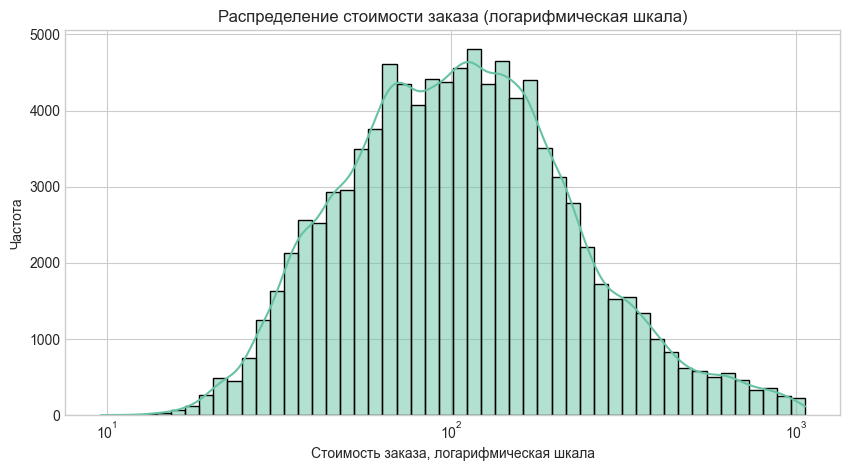

In [132]:
plt.figure(figsize=(10, 5))

plot_data = merged[merged['order_value'] > 0]
plot_data = plot_data[plot_data['order_value'] < plot_data['order_value'].quantile(0.99)]

sns.histplot(plot_data['order_value'], bins=50, kde=True, log_scale=True)
plt.title('Распределение стоимости заказа (логарифмическая шкала)')
plt.xlabel('Стоимость заказа, логарифмическая шкала')
plt.ylabel('Частота')

plt.show()

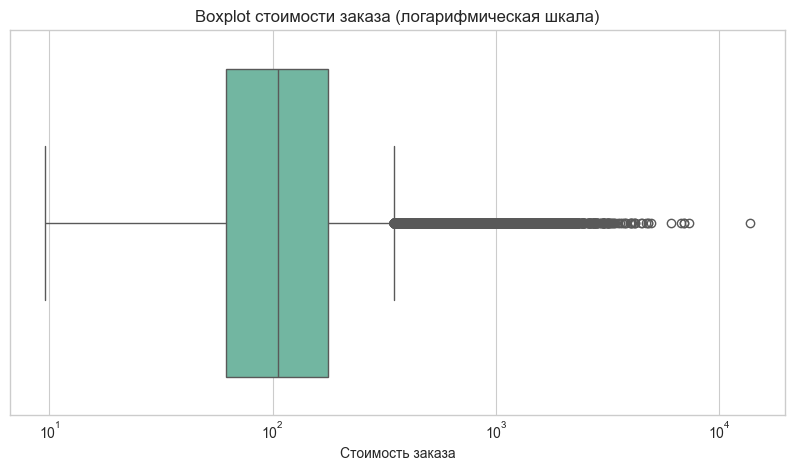

In [133]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=merged[merged['order_value'] > 0]['order_value'])
plt.xscale('log')
plt.title('Boxplot стоимости заказа (логарифмическая шкала)')
plt.xlabel('Стоимость заказа')

plt.show()

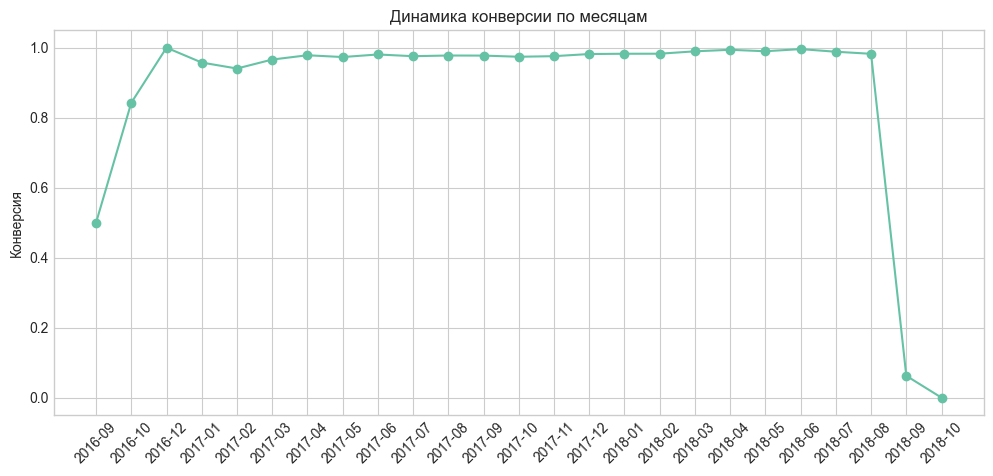

In [134]:
monthly_conversion = merged.groupby('purchase_month')['conversion'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_conversion['purchase_month'].astype(str), 
         monthly_conversion['conversion'], marker='o')
plt.title('Динамика конверсии по месяцам')
plt.xticks(rotation=45)
plt.ylabel('Конверсия')
plt.grid(True)
plt.show()

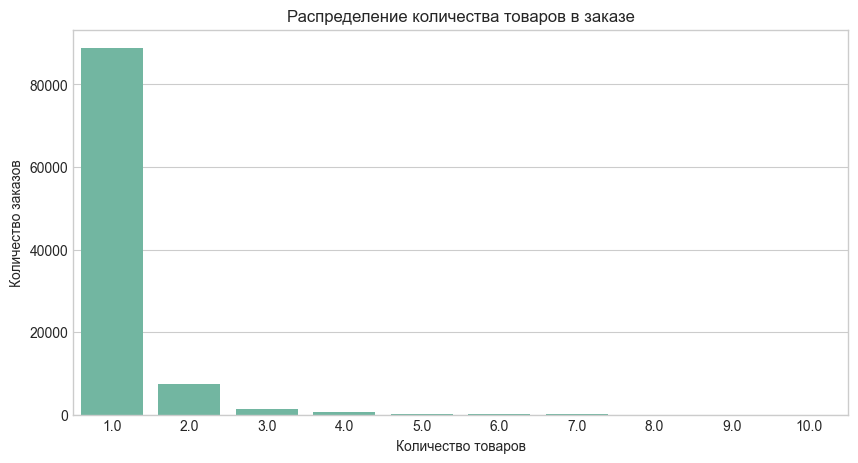

In [135]:
plt.figure(figsize=(10, 5))
sns.countplot(data=merged[merged['item_count'] <= 10], x='item_count')
plt.title('Распределение количества товаров в заказе')
plt.xlabel('Количество товаров')
plt.ylabel('Количество заказов')
plt.show()

## 3. Подготовка к A/B-тесту

Для демонстрации A/B-теста:
1. Создадим искусственное разделение на контрольную и тестовую группы
2. Убедимся, что группы сопоставимы до начала эксперимента
3. Проведем A/B-эксперимент
3. Проведем анализ результатов

**Гипотеза H1:** Внедрение системы рекомендаций увеличивает среднюю стоимость заказа (AOV) на 5%.

**Метрики успеха:** Средняя стоимость заказа (AOV), конверсия (CR), количество товаров в заказе.

**Длительность теста:** 2 недели.

In [136]:
test_start = pd.Timestamp('2017-08-01')
test_end = pd.Timestamp('2017-08-31')
# Период для AA-теста 8 недель
data_start = test_start - timedelta(weeks=8)

test_data = merged[(merged['order_purchase_timestamp'] >= data_start) & 
                   (merged['order_purchase_timestamp'] <= test_end)].copy()

test_data['is_test_period'] = (test_data['order_purchase_timestamp'] >= test_start) & \
                               (test_data['order_purchase_timestamp'] <= test_end)
                               
test_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,conversion,order_value,purchase_month,purchase_weekday,purchase_hour,is_test_period
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,147.90,27.36,...,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,1,175.26,2017-07,6,21,False
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,149.99,19.77,...,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP,1,169.76,2017-07,5,11,False
11,34513ce0c4fab462a55830c0989c7edb,7711cf624183d843aafe81855097bc37,delivered,2017-07-13 19:58:11,2017-07-13 20:10:08,2017-07-14 18:43:29,2017-07-19 14:04:48,2017-08-08,98.00,16.13,...,782987b81c92239d922aa49d6bd4200b,4278,sao paulo,SP,1,114.13,2017-07,3,19,False
30,f70a0aff17df5a6cdd9a7196128bd354,456dc10730fbdba34615447ea195d643,delivered,2017-08-10 11:58:33,2017-08-12 02:45:24,2017-08-17 15:35:07,2017-08-18 14:28:02,2017-08-23,279.00,34.19,...,1974875b4a1d2e2ee6d586e3ba4d7602,5634,sao paulo,SP,1,313.19,2017-08,3,11,True
37,5acce57f8d9dfd55fa48e212a641a69d,295ae9b35379e077273387ff64354b6f,delivered,2017-07-31 21:37:10,2017-08-02 02:56:02,2017-08-03 18:32:48,2017-08-08 21:24:41,2017-08-22,27.90,15.10,...,f1f4f45c8602d0db1329eed1c8e935d4,19780,quata,SP,1,43.00,2017-07,0,21,False


In [137]:
np.random.seed(42)
test_data['group'] = np.random.choice(['control', 'treatment'], size=len(test_data), p=[0.5, 0.5])

test_data.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,...,customer_zip_code_prefix,customer_city,customer_state,conversion,order_value,purchase_month,purchase_weekday,purchase_hour,is_test_period,group
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,147.90,27.36,...,86320,congonhinhas,PR,1,175.26,2017-07,6,21,False,control
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,149.99,19.77,...,18075,sorocaba,SP,1,169.76,2017-07,5,11,False,treatment
11,34513ce0c4fab462a55830c0989c7edb,7711cf624183d843aafe81855097bc37,delivered,2017-07-13 19:58:11,2017-07-13 20:10:08,2017-07-14 18:43:29,2017-07-19 14:04:48,2017-08-08,98.00,16.13,...,4278,sao paulo,SP,1,114.13,2017-07,3,19,False,treatment


In [138]:
np.random.seed(42)
test_data['group'] = 'pre'
mask_test = test_data['is_test_period']
test_data.loc[mask_test, 'group'] = np.random.choice(['control', 'treatment'], 
                                                      size=mask_test.sum(), 
                                                      p=[0.5, 0.5])
test_data.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,...,customer_zip_code_prefix,customer_city,customer_state,conversion,order_value,purchase_month,purchase_weekday,purchase_hour,is_test_period,group
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,147.90,27.36,...,86320,congonhinhas,PR,1,175.26,2017-07,6,21,False,pre
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,149.99,19.77,...,18075,sorocaba,SP,1,169.76,2017-07,5,11,False,pre
11,34513ce0c4fab462a55830c0989c7edb,7711cf624183d843aafe81855097bc37,delivered,2017-07-13 19:58:11,2017-07-13 20:10:08,2017-07-14 18:43:29,2017-07-19 14:04:48,2017-08-08,98.00,16.13,...,4278,sao paulo,SP,1,114.13,2017-07,3,19,False,pre
30,f70a0aff17df5a6cdd9a7196128bd354,456dc10730fbdba34615447ea195d643,delivered,2017-08-10 11:58:33,2017-08-12 02:45:24,2017-08-17 15:35:07,2017-08-18 14:28:02,2017-08-23,279.00,34.19,...,5634,sao paulo,SP,1,313.19,2017-08,3,11,True,control
37,5acce57f8d9dfd55fa48e212a641a69d,295ae9b35379e077273387ff64354b6f,delivered,2017-07-31 21:37:10,2017-08-02 02:56:02,2017-08-03 18:32:48,2017-08-08 21:24:41,2017-08-22,27.90,15.10,...,19780,quata,SP,1,43.00,2017-07,0,21,False,pre


In [139]:
print(f"Всего записей: {len(test_data)}")
print(f"Pre-period: {len(test_data[test_data['group'] == 'pre'])}")
print(f"Control (тест): {len(test_data[test_data['group'] == 'control'])}")
print(f"Treatment (тест): {len(test_data[test_data['group'] == 'treatment'])}")
print(f"\nДаты в данных:")
print(f"Минимальная дата: {test_data['order_purchase_timestamp'].min()}")
print(f"Максимальная дата: {test_data['order_purchase_timestamp'].max()}")

Всего записей: 10864
Pre-period: 6682
Control (тест): 2085
Treatment (тест): 2097

Даты в данных:
Минимальная дата: 2017-06-06 00:11:09
Максимальная дата: 2017-08-30 23:51:01


A/A-тест

In [140]:
pre_data = test_data[test_data['group'] == 'pre']

np.random.seed(5)
pre_data = pre_data.copy()
pre_data['fake_group'] = np.random.choice(['control', 'treatment'], 
                                           size=len(pre_data), 
                                           p=[0.5, 0.5])

print("Проверка сопоставимости групп в pre-period")
print("\nСредняя стоимость заказа:")
control_pre = pre_data[pre_data['fake_group'] == 'control']['order_value']
treatment_pre = pre_data[pre_data['fake_group'] == 'treatment']['order_value']
print(f"Будущая контрольная группа: {control_pre.mean():.2f} (n={len(control_pre)})")
print(f"Будущая тестовая группа: {treatment_pre.mean():.2f} (n={len(treatment_pre)})")

# t-test для pre-period
t_stat_pre, p_value_pre = stats.ttest_ind(treatment_pre, control_pre, equal_var=False)
print(f"\nT-test для pre-period: p-value = {p_value_pre:.4f}")

if p_value_pre > 0.05:
    print("Группы статистически неразличимы до эксперимента")
else:
    print("Группы различаются до эксперимента")

print("\nКонверсия в pre-period:")
conv_control_pre = pre_data[pre_data['fake_group'] == 'control']['conversion'].mean()
conv_treatment_pre = pre_data[pre_data['fake_group'] == 'treatment']['conversion'].mean()
print(f"Будущая контрольная группа: {conv_control_pre:.2%}")
print(f"Будущая тестовая группа: {conv_treatment_pre:.2%}")

Проверка сопоставимости групп в pre-period

Средняя стоимость заказа:
Будущая контрольная группа: 145.62 (n=3332)
Будущая тестовая группа: 150.50 (n=3350)

T-test для pre-period: p-value = 0.2895
Группы статистически неразличимы до эксперимента

Конверсия в pre-period:
Будущая контрольная группа: 97.75%
Будущая тестовая группа: 97.70%


A/B-тест

In [141]:
control_test = test_data[test_data['group'] == 'control']
treatment_test = test_data[test_data['group'] == 'treatment']

print("Результаты A/B-теста (август 2017)")
print(f"\nКонтрольная группа: {len(control_test)} заказов")
print(f"Тестовая группа: {len(treatment_test)} заказов")

# Сравнение AOV
control_aov = control_test['order_value']
treatment_aov = treatment_test['order_value']

print("\nСредняя стоимость заказа (AOV):")
print(f"Контроль: {control_aov.mean():.2f}")
print(f"Тест: {treatment_aov.mean():.2f}")
print(f"Абсолютное изменение: {treatment_aov.mean() - control_aov.mean():.2f}")
print(f"Относительное изменение: {(treatment_aov.mean()/control_aov.mean() - 1)*100:.2f}%")

# t-test
t_stat, p_value_aov = stats.ttest_ind(treatment_aov, control_aov, equal_var=False)
print(f"\nT-test: t-stat = {t_stat:.4f}, p-value = {p_value_aov:.4f}")

if p_value_aov < 0.05:
    print("Различие статистически значимо (p < 0.05)")
else:
    print("Различие не является статистически значимым")

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = group1.mean(), group2.mean()
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (mean1 - mean2) / pooled_std

cohen_d = cohens_d(treatment_aov, control_aov)
print(f"Cohen's d (размер эффекта): {abs(cohen_d):.3f}")

Результаты A/B-теста (август 2017)

Контрольная группа: 2085 заказов
Тестовая группа: 2097 заказов

Средняя стоимость заказа (AOV):
Контроль: 160.48
Тест: 147.78
Абсолютное изменение: -12.70
Относительное изменение: -7.91%

T-test: t-stat = -2.1105, p-value = 0.0349
Различие статистически значимо (p < 0.05)
Cohen's d (размер эффекта): 0.065


In [142]:
# Сравнение конверсии
control_conv = control_test['conversion'].mean()
treatment_conv = treatment_test['conversion'].mean()

print("Анализ конверсии")
print(f"Контроль: {control_conv:.2%}")
print(f"Тест: {treatment_conv:.2%}")
print(f"Изменение: {(treatment_conv - control_conv)*100:.2f} п.п.")

# Z-test для пропорций

count = [treatment_test['conversion'].sum(), control_test['conversion'].sum()]
nobs = [len(treatment_test), len(control_test)]
z_stat, p_value_conv = proportions_ztest(count, nobs)

print(f"\nZ-test: z-stat = {z_stat:.4f}, p-value = {p_value_conv:.4f}")

if p_value_conv < 0.05:
    print("Различие в конверсии статистически значимо")
else:
    print("Различие в конверсии не является статистически значимым")

Анализ конверсии
Контроль: 98.08%
Тест: 97.52%
Изменение: -0.56 п.п.

Z-test: z-stat = -1.2373, p-value = 0.2160
Различие в конверсии не является статистически значимым


Bootstrap

In [143]:
np.random.seed(42)

def bootstrap_ci(data1, data2, metric='mean', n_bootstrap=5000, ci=95):
    differences = []
    n1, n2 = len(data1), len(data2)
    
    for _ in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=n1, replace=True)
        sample2 = np.random.choice(data2, size=n2, replace=True)
        
        if metric == 'mean':
            diff = sample2.mean() - sample1.mean()
        elif metric == 'median':
            diff = np.median(sample2) - np.median(sample1)
        
        differences.append(diff)
    
    lower = np.percentile(differences, (100 - ci) / 2)
    upper = np.percentile(differences, 100 - (100 - ci) / 2)
    
    return lower, upper, differences

# Bootstrap для AOV
lower_aov, upper_aov, diffs_aov = bootstrap_ci(control_aov.values, treatment_aov.values, metric='mean')

print(f"Разница в AOV (тест - контроль):")
print(f"Точечная оценка: {treatment_aov.mean() - control_aov.mean():.2f}")
print(f"95% ДИ: [{lower_aov:.2f}, {upper_aov:.2f}]")

if lower_aov > 0:
    print("ДИ полностью выше нуля, эффект положительный")
elif upper_aov < 0:
    print("ДИ полностью ниже нуля, эффект отрицательный")
else:
    print("ДИ пересекает ноль, эффект неопределенный")

Разница в AOV (тест - контроль):
Точечная оценка: -12.70
95% ДИ: [-24.34, -1.07]
ДИ полностью ниже нуля, эффект отрицательный


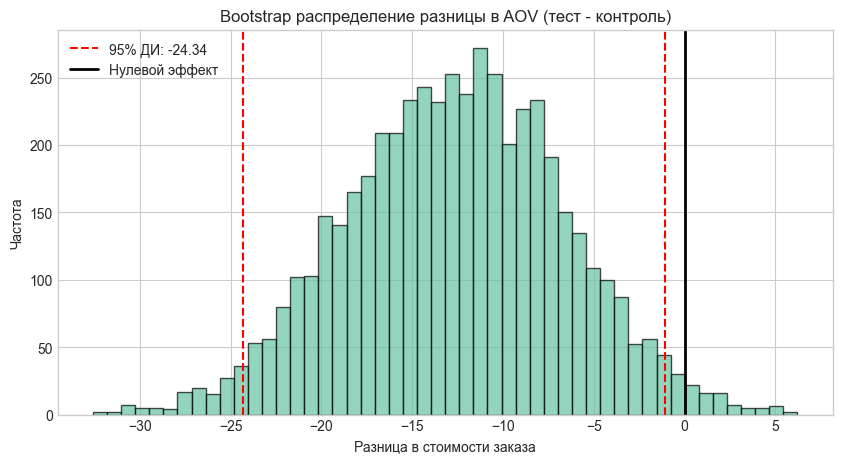

In [144]:

plt.figure(figsize=(10, 5))
plt.hist(diffs_aov, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(lower_aov, color='red', linestyle='--', label=f'95% ДИ: {lower_aov:.2f}')
plt.axvline(upper_aov, color='red', linestyle='--')
plt.axvline(0, color='black', linestyle='-', linewidth=2, label='Нулевой эффект')
plt.title('Bootstrap распределение разницы в AOV (тест - контроль)')
plt.xlabel('Разница в стоимости заказа')
plt.ylabel('Частота')
plt.legend()
plt.show()

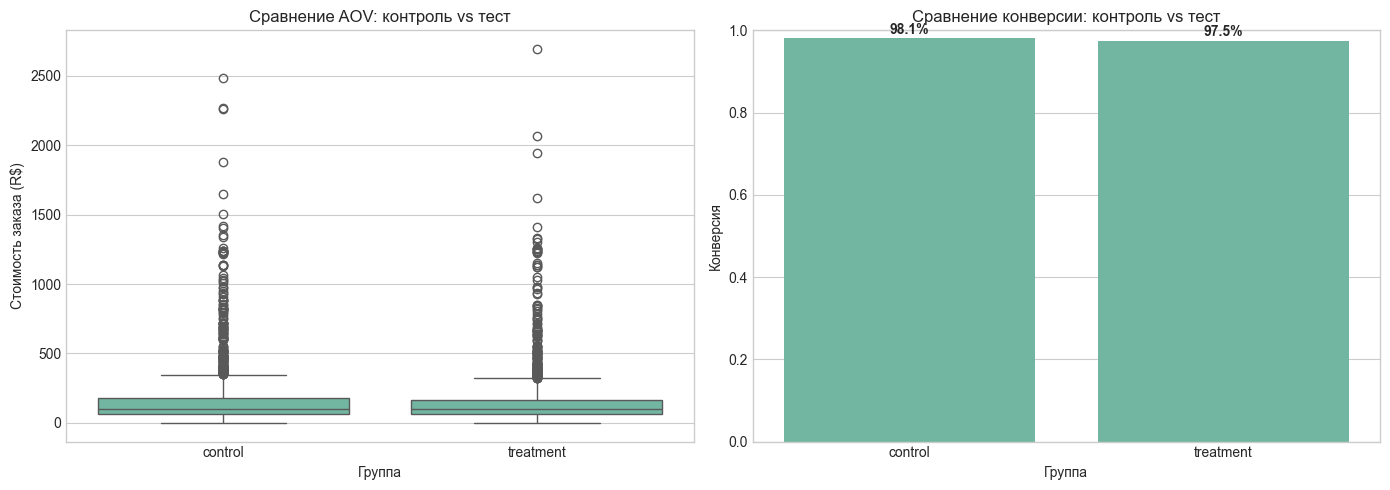

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AOV boxplot
sns.boxplot(data=test_data[test_data['group'].isin(['control', 'treatment'])], 
            x='group', y='order_value', ax=axes[0])
axes[0].set_title('Сравнение AOV: контроль vs тест')
axes[0].set_xlabel('Группа')
axes[0].set_ylabel('Стоимость заказа (R$)')

# Конверсия barplot
conv_data = test_data[test_data['group'].isin(['control', 'treatment'])].groupby('group')['conversion'].mean().reset_index()
sns.barplot(data=conv_data, x='group', y='conversion', ax=axes[1])
axes[1].set_title('Сравнение конверсии: контроль vs тест')
axes[1].set_xlabel('Группа')
axes[1].set_ylabel('Конверсия')
axes[1].set_ylim(0, 1)

for i, row in conv_data.iterrows():
    axes[1].text(i, row['conversion'] + 0.01, f"{row['conversion']:.1%}", 
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [146]:
print("Итоговые результаты A/B-ТЕСТА")

print(f"\nПериод теста: август 2017")
print(f"Объем выборки: контроль = {len(control_test)}, тест = {len(treatment_test)}")

print(f"\nМетрика: Средняя стоимость заказа (AOV)")
print(f"Контроль: {control_aov.mean():.2f} R$")
print(f"Тест: {treatment_aov.mean():.2f} R$")
print(f"Изменение: {(treatment_aov.mean()/control_aov.mean() - 1)*100:.2f}%")
print(f"p-value: {p_value_aov:.4f}")

print(f"\nМетрика: Конверсия")
print(f"Контроль: {control_conv:.2%}")
print(f"Тест: {treatment_conv:.2%}")
print(f"Изменение: {(treatment_conv - control_conv)*100:.2f} п.п.")
print(f"p-value: {p_value_conv:.4f}")

print(f"\nРазмер эффекта (Cohen's d): {abs(cohen_d):.3f}")
if abs(cohen_d) < 0.2:
    print("Очень маленький эффект")
elif abs(cohen_d) < 0.5:
    print("Маленький эффект")
elif abs(cohen_d) < 0.8:
    print("Средний эффект")
else:
    print("Большой эффект")

Итоговые результаты A/B-ТЕСТА

Период теста: август 2017
Объем выборки: контроль = 2085, тест = 2097

Метрика: Средняя стоимость заказа (AOV)
Контроль: 160.48 R$
Тест: 147.78 R$
Изменение: -7.91%
p-value: 0.0349

Метрика: Конверсия
Контроль: 98.08%
Тест: 97.52%
Изменение: -0.56 п.п.
p-value: 0.2160

Размер эффекта (Cohen's d): 0.065
Очень маленький эффект


In [147]:
print("Рекомендации:")

if p_value_aov < 0.05 and treatment_aov.mean() > control_aov.mean():
    print("AOV значимо вырос — рекомендуется rollout на всех пользователей")
elif p_value_aov < 0.05 and treatment_aov.mean() < control_aov.mean():
    print("AOV значимо снизился — требуется анализ причин, rollout не рекомендуется")
else:
    print("Изменение AOV незначимо — требуется увеличить длительность теста или размер выборки")

if p_value_conv < 0.05 and treatment_conv > control_conv:
    print("Конверсия значимо выросла — дополнительный аргумент в пользу rollout")
elif p_value_conv < 0.05 and treatment_conv < control_conv:
    print("Конверсия значимо снизилась — требуется дополнительное исследование")


Рекомендации:
AOV значимо снизился — требуется анализ причин, rollout не рекомендуется
